# 03. Modeling — Batch 1 안에서 선택, Batch 2·3에서 한 번 평가

실험은 `python src/train.py`(약 6분, 분할 민감도 20회 포함)와 `python src/batch_checks.py`(약 2분)로 재현되며, 결과 표는 모두 `results/`에 저장됩니다. 이 노트북은 그 결과를 읽어 해석하고 그림을 만듭니다.

**평가 프로토콜 (과제 원문 기준)**

| 단계 | 데이터 | 하는 일 |
|---|---|---|
| ① 분할 | Batch 1 (36셀, 충전 정책 20개) | 정책 단위로 **Dev 27셀(15정책) / Hold-out 9셀(5정책)**. 정책 = 전체 문자열 `C1(SOC%)-C2`. 같은 정책 셀은 양쪽에 섞이지 않음(첫 단계만 같은 sibling 정책은 가로지름, 아래 §1) |
| ② Train (Batch 1 CV) | Dev 27셀 | 정책 그룹 5-fold CV × 10회 반복. target(raw/log)과 Ridge 피처 그룹을 **CV MAPE**로 선택 |
| ③ Valid (Batch 1 Hold-out) | Hold-out 9셀 | 후보를 Dev로 학습해 Hold-out MAPE 계산 → 선택 규칙으로 최종 모델 결정(§3) |
| ④ Test (Batch 2) — 필수 | Batch 2 (39셀) | 최종 모델을 Batch 1 전체(36셀)로 재학습 후 **한 번만** 예측 |
| ⑤ Test (Batch 3) — 추가(선택) | Batch 3 (44셀 / 이상치 제외 40셀) | 같은 최종 모델로 한 번만 예측. 선택·검증에 쓰지 않음 |

Batch 2·3는 피처·target·모델 선택 어디에도 쓰지 않습니다. 다른 후보의 Batch 2·3 수치는 **참고용**(선택 미사용)으로만 표시합니다.

후보 모델은 DAY 1 보고서 「모델 설계 전략 §3」 그대로입니다: 학습 중앙값 상수 기준선, `ln_dq_variance` 단일 피처 Linear, 확장 피처 Ridge(전진 선택), Random Forest(`max_depth=3`, `min_samples_leaf=3`).

In [1]:
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
RES, FIG = ROOT / 'results', ROOT / 'figures'
if not (RES / 'split_sensitivity.csv').exists():
    subprocess.run([sys.executable, str(ROOT / 'src' / 'train.py')], check=True, cwd=ROOT)
if not (RES / 'qdlin_batch_check.csv').exists():
    subprocess.run([sys.executable, str(ROOT / 'src' / 'batch_checks.py')], check=True, cwd=ROOT)

BATCH_STYLE = {'Batch 1': ('#2a78d6', 'o'), 'Batch 2': ('#eb6834', 's'), 'Batch 3': ('#1baf7a', '^')}
FINAL_COLOR, REF_COLOR = '#4a3aa7', '#8a8a8a'
TARGET_MAPE = 9.1
plt.rcParams.update({'axes.grid': True, 'grid.alpha': .2, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 90)

split_tab = pd.read_csv(RES / 'holdout_split.csv')
cv = pd.read_csv(RES / 'cv_batch1.csv')
steps = pd.read_csv(RES / 'ridge_feature_selection.csv')
selection = pd.read_csv(RES / 'model_selection.csv')
report = pd.read_csv(RES / 'model_performance.csv')
perf = pd.read_csv(RES / 'model_performance_all.csv')
pred = pd.read_csv(RES / 'predictions.csv')
coef = pd.read_csv(RES / 'model_coefficients.csv')
breakdown = pd.read_csv(RES / 'batch2_error_breakdown.csv')
lobo = pd.read_csv(RES / 'leave_one_batch_out.csv')
recal = pd.read_csv(RES / 'batch2_recalibration.csv')
sens = pd.read_csv(RES / 'split_sensitivity.csv')
qdlin = pd.read_csv(RES / 'qdlin_batch_check.csv')
b3out = pd.read_csv(RES / 'batch3_outlier_check.csv')
FINAL = selection.loc[selection.final, 'model'].iloc[0]
LINEAR = 'Linear (ln Var ΔQ)'
ORDER = ['Baseline (train median)', LINEAR, 'Ridge (extended)', 'Random Forest']
print('Final model:', FINAL, '| target:', selection.loc[selection.final, 'target'].iloc[0],
      '| features:', selection.loc[selection.final, 'features'].iloc[0])

Final model: Ridge (extended) | target: log | features: ln_dq_variance, qd_100, early_qd_slope_clean


## 1. Batch 1 분할: 정책 단위 Dev / Hold-out

과제 원문은 Valid를 CV가 아닌 **Hold-out**으로 두라고 하고, 그 이유로 "같은 충전 프로토콜 셀이 train/valid에 나뉘어 들어가는 누수"를 듭니다. 그래서 셀이 아니라 **충전 정책 단위**로 나눕니다.

- 규칙(`features.holdout_split`, seed 0): 20개 정책을 정책 평균 수명으로 정렬 → 4개씩 5개 수명 구간 → 구간마다 정책 1개를 무작위로 Hold-out에 배정.
- 정책은 전체 문자열 `C1(SOC%)-C2`입니다. 같은 정책의 셀은 섞이지 않지만, 첫 충전 단계(C1·SOC)만 같은 *sibling* 정책은 분할을 가로지릅니다(Hold-out 5정책 중 3개: 7C(40%)-3C↔7C(40%)-3.6C, 5.4C(60%)-3.6C↔5.4C(60%)-3C, 6C(50%)-3.6C↔6C(50%)-3C). 분할·시드는 Batch 2 결과를 본 뒤라 바꾸지 않았습니다.
- 36셀뿐이라 완전 무작위로 나누면 Hold-out 수명이 한쪽에 쏠릴 수 있어, 수명 구간별로 하나씩 뽑았습니다.

In [2]:
roles = split_tab.groupby('role').agg(cells=('cell_id', 'size'), policies=('policy', 'nunique'),
                                     life_min=('cycle_life', 'min'), life_median=('cycle_life', 'median'),
                                     life_max=('cycle_life', 'max'))
assert not set(split_tab[split_tab.role == 'dev'].policy) & set(split_tab[split_tab.role == 'holdout'].policy)
display(roles)
split_tab[split_tab.role == 'holdout'].groupby(['life_bin', 'policy']).cycle_life.apply(list).to_frame('holdout cells (cycle life)')

,cells,policies,life_min,life_median,life_max
role,,,,,
dev,27,15,534.0,757.0,1074.0
holdout,9,5,648.0,788.0,1014.0


,,holdout cells (cycle life)
life_bin,policy,
0,7C(40%)-3C,"[648.0, 704.0]"
1,5.4C(70%)-3C,"[691.0, 788.0]"
2,6C(50%)-3.6C,"[709.0, 876.0]"
3,5.4C(60%)-3.6C,"[857.0, 862.0]"
4,6C(30%)-3.6C,[1014.0]


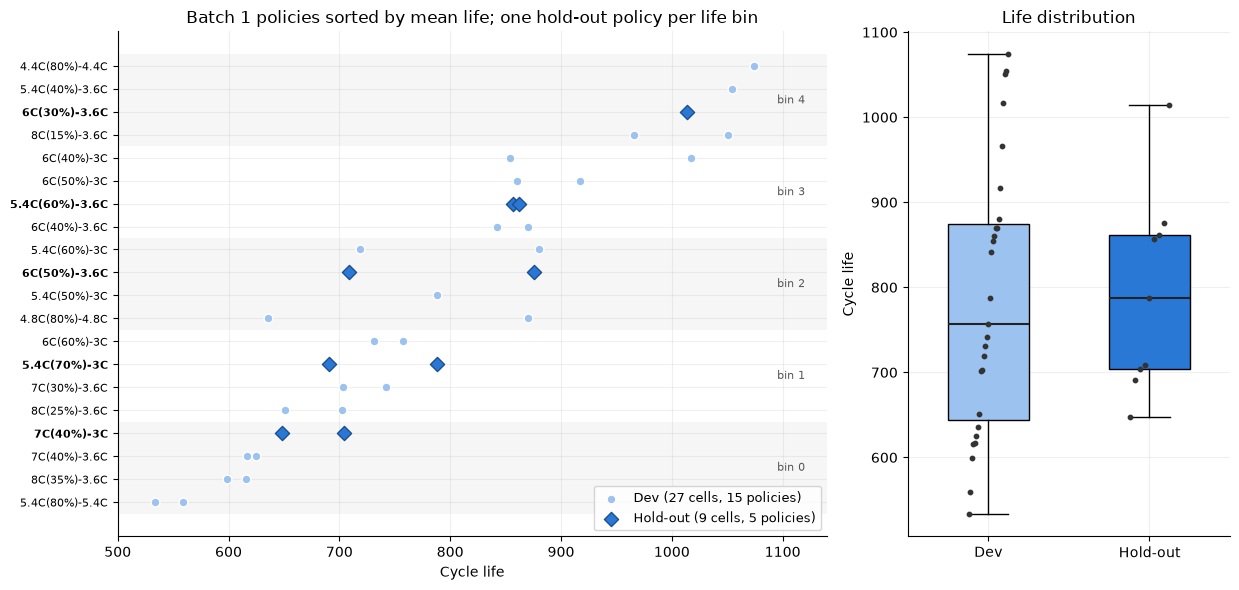

In [3]:
pol = split_tab.groupby('policy').agg(mean_life=('cycle_life', 'mean'), role=('role', 'first'),
                                     life_bin=('life_bin', 'first')).sort_values(['mean_life', 'policy']).reset_index()
pos = {p: i for i, p in enumerate(pol.policy)}
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12.5, 6), gridspec_kw={'width_ratios': [2.2, 1]})
for b in sorted(pol.life_bin.unique()):
    rows = pol.index[pol.life_bin == b]
    ax.axhspan(rows.min() - .5, rows.max() + .5, color='#888', alpha=.07 if b % 2 == 0 else 0, lw=0)
    ax.text(1095, np.mean(rows), f'bin {b}', va='center', fontsize=8, color='#555')
for role, color, marker, size in (('dev', '#9cc3ef', 'o', 40), ('holdout', '#2a78d6', 'D', 52)):
    p = split_tab[split_tab.role == role]
    ax.scatter(p.cycle_life, p.policy.map(pos), color=color, marker=marker, s=size, edgecolor='#1d4f8f' if role == 'holdout' else 'white',
               linewidth=1, zorder=3, label=f"{'Dev' if role == 'dev' else 'Hold-out'} ({len(p)} cells, {p.policy.nunique()} policies)")
ax.set_yticks(range(len(pol)), pol.policy, fontsize=8)
for tick, role in zip(ax.get_yticklabels(), pol.role):
    if role == 'holdout':
        tick.set_fontweight('bold')
ax.set_xlim(500, 1140)
ax.set_xlabel('Cycle life')
ax.set_title('Batch 1 policies sorted by mean life; one hold-out policy per life bin')
ax.legend(loc='lower right', fontsize=9)
data = [split_tab[split_tab.role == r].cycle_life for r in ('dev', 'holdout')]
bp = ax2.boxplot(data, tick_labels=['Dev', 'Hold-out'], widths=.5, patch_artist=True,
                 medianprops={'color': '#222', 'lw': 1.5})
for patch, color in zip(bp['boxes'], ('#9cc3ef', '#2a78d6')):
    patch.set_facecolor(color)
for i, d in enumerate(data, start=1):
    ax2.scatter(np.full(len(d), i) + np.linspace(-.12, .12, len(d)), d, color='#333', s=10, zorder=3)
ax2.set_ylabel('Cycle life')
ax2.set_title('Life distribution')
fig.tight_layout()
fig.savefig(FIG / 'm0_holdout_split.png', dpi=150, bbox_inches='tight')
plt.show()

Hold-out 9셀(648–1,014회, 중앙값 788회)이 Dev 27셀(534–1,074회, 중앙값 757회)의 수명 범위 안쪽을 고르게 덮습니다. 다만 Batch 1 양 끝(534–625회 최단 정책, 1,051–1,074회 최장 정책)은 Dev에만 있습니다.

## 2. Train (Batch 1 CV): Dev 정책 그룹 CV로 target과 피처 선택

- CV: Dev 27셀에서 `GroupKFold(5, shuffle=True)`를 정책 그룹으로 10회 반복, out-of-fold MAPE의 평균. Hold-out 셀은 CV에 들어가지 않습니다.
- 각 모델마다 `cycle_life`와 `log(cycle_life)` 학습을 비교해 CV MAPE가 낮은 쪽을 씁니다(오차는 사이클 단위로 역변환 후 계산).

In [4]:
cv.set_index(['model', 'target'])[['n_features', 'cv_mape', 'cv_mape_sd', 'cv_rmse', 'chosen_target']].round(2)

n_features  cv_mape  cv_mape_sd  cv_rmse  chosen_target
model                   target                                                         
Baseline (train median) raw              1    19.45        0.89   172.60           True
Linear (ln Var ΔQ)      raw              1     9.46        0.34    96.47           True
                        log              1     9.65        0.32    98.32          False
Ridge (extended)        raw              3     7.20        0.56    73.00          False
                        log              3     6.56        0.26    67.25           True
Random Forest           raw             10    13.53        0.72   126.46          False
                        log             10    13.00        0.83   125.34           True

**Ridge 확장 피처의 전진 선택.** `ln_dq_variance`에서 출발해 각 단계에서 Dev CV MAPE를 가장 많이 낮추는 그룹을 하나씩 채택하고, 더 낮아지지 않으면 멈춥니다(DAY 1: "검증 오차를 줄일 때만 채택"). 선택된 target(log) 기준 기록입니다.

In [5]:
ridge_target = cv.loc[(cv.model == 'Ridge (extended)') & cv.chosen_target, 'target'].iloc[0]
steps[steps.target == ridge_target][['step', 'tried', 'cv_mape', 'adopted']].round(2)

,step,tried,cv_mape,adopted
13,0,baseline,9.76,True
14,1,fade,12.45,False
15,1,capacity,7.30,True
16,1,resistance,10.57,False
17,1,temperature,10.09,False
18,1,charging,13.10,False
19,2,fade,6.56,True
20,2,resistance,6.69,False
21,2,temperature,7.72,False
22,2,charging,8.36,False


`qd_100`(용량, 9.76% → 7.3%)과 Qd 기울기(`early_qd_slope_clean`, → 6.56%)가 채택됐고, 저항·온도·충전 그룹은 Dev CV MAPE를 더 낮추지 못해 탈락했습니다.

## 3. Valid (Batch 1 Hold-out)와 최종 모델 선택

**선택 규칙(결과를 보기 전에 고정).** 각 후보를 Dev 27셀로 학습해 Hold-out 9셀 MAPE(Valid)를 계산하고, 최저 Valid MAPE + 1.0%p 이내 후보 중 가장 단순한 모델(Linear < Ridge < Random Forest)을 고릅니다(상수 기준선은 비교용). RF는 후보 피처 10개 전체를 쓰고(트리가 자체 선택), Ridge는 전진 선택으로 3개를 고릅니다 — DAY 1 보고서 설계.

In [6]:
selection.set_index('model')[['complexity', 'target', 'n_features', 'train_cv_mape', 'train_cv_mape_sd',
                               'valid_mape', 'valid_rmse', 'within_1pp', 'final']].round(2)

,complexity,target,n_features,train_cv_mape,train_cv_mape_sd,valid_mape,valid_rmse,within_1pp,final
model,,,,,,,,,
Baseline (train median),0,raw,1,19.45,0.89,11.93,117.16,False,False
Linear (ln Var ΔQ),1,raw,1,9.46,0.34,7.91,70.47,False,False
Ridge (extended),2,log,3,6.56,0.26,6.50,66.99,True,True
Random Forest,3,log,10,13.00,0.83,6.67,77.86,True,False


**보조: sibling 정책 유무별 Valid MAPE (선택에 미사용).** Hold-out 정책 중 첫 충전 단계(C1·SOC)가 같은 정책이 Dev에도 있는 셀(6셀)과 없는 셀(3셀)을 나눠, Dev로 학습한 Hold-out 예측의 MAPE를 비교합니다(`predictions.csv`, 재학습 없음).

In [7]:
first = lambda p: p.split('-')[0]
dev_first = {first(p) for p in split_tab[split_tab.role == 'dev'].policy}
ho = pred[pred.split == 'holdout'].copy()
ho['sibling_in_dev'] = ho.policy.map(first).isin(dev_first)
sib = ho.pivot_table(index='model', columns='sibling_in_dev', values='abs_pct_error', aggfunc=['mean', 'size'])
sib.columns = [f"{'MAPE' if a == 'mean' else 'cells'} ({'sibling 있음' if b else 'sibling 없음'})" for a, b in sib.columns]
display(sib.round(2))
sib_mape = ho.groupby(['model', 'sibling_in_dev']).abs_pct_error.mean()

,MAPE (sibling 없음),MAPE (sibling 있음),cells (sibling 없음),cells (sibling 있음)
model,,,,
Baseline (train median),12.94,11.43,3,6
Linear (ln Var ΔQ),7.94,7.89,3,6
Random Forest,7.26,6.37,3,6
Ridge (extended),7.62,5.94,3,6


Ridge는 sibling 있는 6셀 5.9%, 없는 3셀 7.6%입니다. 3셀이라 결론은 아니지만 Valid 6.5%는 다소 낙관적일 수 있습니다. 같은 경향이 Random Forest에도 있고 Linear는 차이가 없습니다.

In [8]:
coef.pivot_table(index='feature', columns='model', values='weight').round(4).fillna('')

model,Linear (ln Var ΔQ),Random Forest,Ridge (extended)
feature,,,
c1,,0.0003,
c2,,0.0089,
charge_current_10,,0.0234,
early_charge_time_clean,,0.0431,
early_qd_slope_clean,,0.0116,-0.0267
early_tavg_mean,,0.0106,
ir_100,,0.0109,
ln_dq_variance,-121.1905,0.8354,-0.1693
qd_100,,0.0487,0.0676


- 최종 모델은 **Ridge (log target, `ln_dq_variance` + `qd_100` + `early_qd_slope_clean`)**입니다. Ridge가 Valid MAPE 자체도 최저(6.50 vs RF 6.67, Linear 7.91)여서 1%p 단순성 규칙은 결과를 바꾸지 않았습니다.
- Ridge는 Dev CV에서도 가장 낮습니다(6.56% vs Linear 9.46%, Random Forest 13.00%).
- 최종 모델은 Batch 1 전체 36셀로 다시 학습해 Batch 2·3를 예측합니다. 위 계수는 이 재학습 모델 기준이며, Ridge는 log 수명 공간의 표준화 계수입니다. `qd_100`의 계수가 **양수**(초기 용량이 클수록 수명이 길다)라는 점이 Batch 2 결과를 이해하는 열쇠입니다.

## 4. 성능 결과 — Regression Reporting format

`results/model_performance.csv`에서 바로 만든 표입니다. MAPE = `mean(|ŷ − y| / y) × 100`.

In [9]:
note_extra = {
    'Train (Batch 1 CV)': 'Dev 27셀(15정책), 정책 그룹 5-fold CV × 10회 평균',
    'Valid (Batch 1 Hold-out)': 'Hold-out 9셀(5정책), Dev로 학습',
    'Test (Batch 2)': '39셀, Batch 1 전체(36셀) 재학습 후 1회 평가',
    'Gap (Train-Valid)': '(+) : 과적합 의심 → 과적합 징후 없음',
    'Gap (Valid-Test)': '(+) : 배치간 일반화 저하 의심 → 일반화 크게 저하',
    'Gap (Target-Test)': 'Target : 원논문 9.1%',
}
def val(x, signed):
    return f'{x:+.1f}' if signed else f'{x:.1f}'
reg = report[report.section == 'Regression']
lines = ['| 구분 | MAPE (%) | 비고 |', '| --- | --- | --- |']
for _, r in reg.iterrows():
    lines.append(f"| {r['item']} | {val(r.mape, r['item'].startswith('Gap'))} | {note_extra[r['item']]} |")
display(Markdown('\n'.join(lines)))
report

| 구분 | MAPE (%) | 비고 |
| --- | --- | --- |
| Train (Batch 1 CV) | 6.6 | Dev 27셀(15정책), 정책 그룹 5-fold CV × 10회 평균 |
| Valid (Batch 1 Hold-out) | 6.5 | Hold-out 9셀(5정책), Dev로 학습 |
| Test (Batch 2) | 41.4 | 39셀, Batch 1 전체(36셀) 재학습 후 1회 평가 |
| Gap (Train-Valid) | -0.1 | (+) : 과적합 의심 → 과적합 징후 없음 |
| Gap (Valid-Test) | +34.9 | (+) : 배치간 일반화 저하 의심 → 일반화 크게 저하 |
| Gap (Target-Test) | +32.3 | Target : 원논문 9.1% |

,section,item,mape,note
0,Regression,Train (Batch 1 CV),6.6,"Dev 27셀, 정책 그룹 5-fold CV x10 평균"
1,Regression,Valid (Batch 1 Hold-out),6.5,Hold-out 9셀 (정책 5개)
2,Regression,Test (Batch 2),41.4,39셀
3,Regression,Gap (Train-Valid),-0.1,(+) : 과적합 의심; Valid - Train
4,Regression,Gap (Valid-Test),34.9,(+) : 배치간 일반화 저하 의심; Test(B2) - Valid
5,Regression,Gap (Target-Test),32.3,Target : 원논문 9.1% (과제 지정); Test(B2) - Target
6,Batch 3,Test (Batch 3),11.7,40셀(이상치 제외); 전체 44셀 = 11.9%
7,Batch 3,Gap (Batch2-Batch3),-29.7,Test 성능 간 비교; Test(B3) - Test(B2); 전체 44셀 기준 -29.5
8,Batch 3,Gap (Target-Test),2.6,"Batch 3 기준, 원논문 9.1% 대비; Test(B3) - Target; 전체 44셀 기준 +2.8"


Gap 계산식 (MAPE는 낮을수록 좋으므로 **(+) = 나빠짐**이 되도록 정의): Gap(Train-Valid) = Valid − Train, Gap(Valid-Test) = Test(B2) − Valid, Gap(Target-Test) = Test(B2) − 9.1. Target 9.1%는 과제가 지정한 원논문 성능입니다.

- **Train ≈ Valid** (6.6% vs 6.5%): Batch 1 안에서는 과적합 징후가 없습니다.
- **Valid → Test(B2)에서 +34.9%p**: 같은 배치 안 검증으로는 보이지 않던 배치 간 일반화 실패입니다(원인은 7절).
- **Target 대비 +32.3%p**: 과제의 Batch 2(2018-02-20)는 원논문 124셀에 없는 배치입니다. 논문은 같은 배치들을 섞어 나눈 primary test로 평가했고, 여기서는 Batch 1(36셀)만으로 *다른 배치*를 평가하므로 비교 조건이 다릅니다.

## 5. Batch 3 추가 평가 (선택) — Reporting format

같은 최종 모델(Batch 1 전체 재학습)로 Batch 3를 한 번 예측합니다. 헤드라인은 원논문 secondary test와 같은 규모인 **이상치 제외 40셀**이고, 전체 44셀 값을 비고에 함께 적습니다.

In [10]:
b3_all = perf[(perf.model == FINAL) & (perf.stage == 'test_b3_all')].mape.iloc[0]
b2 = report.set_index('item').loc['Test (Batch 2)', 'mape']
b3_note = {
    'Test (Batch 3)': f'40셀(이상치 4셀 제외); 전체 44셀 = {b3_all:.1f}%',
    'Gap (Batch2-Batch3)': f'Test 성능 간 비교; 전체 44셀 기준 {b3_all - b2:+.1f}',
    'Gap (Target-Test)': f'Batch 3 기준, 원논문 성능 비교 (Target 9.1%); 전체 44셀 기준 {b3_all - TARGET_MAPE:+.1f}',
}
lines = ['| 구분 |  | MAPE (%) | 비고 |', '| --- | --- | --- | --- |']
for i, r in report.iterrows():
    item, signed = r['item'], r['item'].startswith('Gap')
    note = b3_note[item] if r.section == 'Batch 3' else note_extra[item]
    left, right = ('', item) if signed else (item, '')
    lines.append(f"| {left} | {right} | {val(r.mape, signed)} | {note} |")
display(Markdown('\n'.join(lines)))

| 구분 |  | MAPE (%) | 비고 |
| --- | --- | --- | --- |
| Train (Batch 1 CV) |  | 6.6 | Dev 27셀(15정책), 정책 그룹 5-fold CV × 10회 평균 |
| Valid (Batch 1 Hold-out) |  | 6.5 | Hold-out 9셀(5정책), Dev로 학습 |
| Test (Batch 2) |  | 41.4 | 39셀, Batch 1 전체(36셀) 재학습 후 1회 평가 |
|  | Gap (Train-Valid) | -0.1 | (+) : 과적합 의심 → 과적합 징후 없음 |
|  | Gap (Valid-Test) | +34.9 | (+) : 배치간 일반화 저하 의심 → 일반화 크게 저하 |
|  | Gap (Target-Test) | +32.3 | Target : 원논문 9.1% |
| Test (Batch 3) |  | 11.7 | 40셀(이상치 4셀 제외); 전체 44셀 = 11.9% |
|  | Gap (Batch2-Batch3) | -29.7 | Test 성능 간 비교; 전체 44셀 기준 -29.5 |
|  | Gap (Target-Test) | +2.6 | Batch 3 기준, 원논문 성능 비교 (Target 9.1%); 전체 44셀 기준 +2.8 |

추가 Gap 계산식: Gap(Batch2-Batch3) = Test(B3) − Test(B2) (**(−) = Batch 3가 더 좋음**), Gap(Target-Test, Batch 3) = Test(B3) − 9.1.

**44셀 vs 40셀, 그리고 참고 후보.** 아래 표는 모든 후보의 수치입니다. 최종 모델 외의 Batch 2·3 수치는 **선택에 쓰지 않은 참고값**입니다. 대괄호는 셀 단위 부트스트랩(2,000회) 95% 구간입니다.

In [11]:
def ci(r):
    return f"{r.mape:.1f} [{r.mape_ci_low:.1f}–{r.mape_ci_high:.1f}]" if pd.notna(r.mape_ci_low) else f"{r.mape:.1f}"
stages = {'train_cv': 'Train CV (Dev 27)', 'valid': 'Valid (Hold-out 9)', 'test_b2': 'Test B2 (39)',
          'test_b3_clean': 'Test B3 (40)', 'test_b3_all': 'Test B3 (44)'}
t = perf[perf.stage.isin(stages)].assign(txt=lambda d: d.apply(ci, axis=1), stage=lambda d: d.stage.map(stages))
t = t.pivot_table(index='model', columns='stage', values='txt', aggfunc='first').reindex(ORDER)[list(stages.values())]
t.index = [f'★ {m} (final)' if m == FINAL else f'{m} (참고)' for m in t.index]
t

stage,Train CV (Dev 27),Valid (Hold-out 9),Test B2 (39),Test B3 (40),Test B3 (44)
Baseline (train median) (참고),19.4,11.9,58.7 [50.4–66.6],22.9 [18.3–27.9],24.5 [19.8–29.7]
Linear (ln Var ΔQ) (참고),9.5,7.9,25.6 [20.0–31.0],12.1 [9.1–15.4],12.1 [9.1–15.5]
★ Ridge (extended) (final),6.6,6.5,41.4 [36.2–46.0],11.7 [8.9–14.8],11.9 [9.0–15.1]
Random Forest (참고),13.0,6.7,32.1 [27.7–36.5],17.0 [13.0–21.5],18.5 [14.4–23.0]


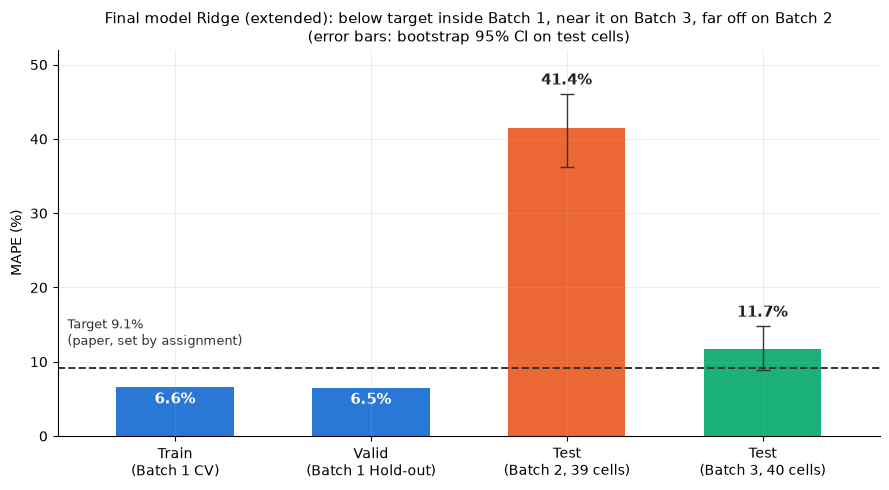

In [12]:
fin = perf[perf.model == FINAL].set_index('stage')
lin = perf[perf.model == LINEAR].set_index('stage')
bars = [('Train\n(Batch 1 CV)', fin.loc['train_cv', 'mape'], BATCH_STYLE['Batch 1'][0], None),
        ('Valid\n(Batch 1 Hold-out)', fin.loc['valid', 'mape'], BATCH_STYLE['Batch 1'][0], None),
        ('Test\n(Batch 2, 39 cells)', fin.loc['test_b2', 'mape'], BATCH_STYLE['Batch 2'][0], fin.loc['test_b2']),
        ('Test\n(Batch 3, 40 cells)', fin.loc['test_b3_clean', 'mape'], BATCH_STYLE['Batch 3'][0], fin.loc['test_b3_clean'])]
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(bars))
for i, (label, v, color, row) in enumerate(bars):
    err = None if row is None else [[v - row.mape_ci_low], [row.mape_ci_high - v]]
    ax.bar(i, v, .6, color=color, yerr=err, capsize=5, ecolor='#333', error_kw={'lw': 1})
    if row is None:  # short Batch 1 bars: label inside the bar, clear of the target line
        ax.text(i, v - .6, f'{v:.1f}%', ha='center', va='top', fontsize=11, fontweight='bold', color='white')
    else:
        ax.text(i, row.mape_ci_high + .8, f'{v:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#222')
ax.axhline(TARGET_MAPE, color='#333', ls='--', lw=1.4)
ax.text(-.55, TARGET_MAPE + 2.6, f'Target {TARGET_MAPE}%\n(paper, set by assignment)', ha='left', va='bottom', fontsize=9, color='#333')
ax.set_xticks(x, [b[0] for b in bars])
ax.set_ylabel('MAPE (%)')
ax.set_ylim(0, 52)
ax.set_xlim(-.6, len(bars) - .4)
ax.set_title(f'Final model {FINAL}: below target inside Batch 1, near it on Batch 3, far off on Batch 2\n'
             '(error bars: bootstrap 95% CI on test cells)', fontsize=11)
fig.tight_layout()
fig.savefig(FIG / 'm2_paper_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Batch 3 주의사항 점검: Qdlin 시작점과 이상치

과제는 Batch 3에 대해 세 가지를 주의하라고 합니다. 수명 분포 차이는 7절 오류 분석에서 다루고, 나머지 둘은 `src/batch_checks.py`가 원본 `.mat`을 직접 읽어 점검했습니다.

### 6-1. Qdlin 충전 커브 시작 시점
`Qdlin`은 방전 용량을 전압 격자 `Vdlin`에 보간한 곡선입니다. 우리 핵심 피처는 **같은 셀**의 두 곡선 차이 ΔQ = Qdlin(100) − Qdlin(10)의 분산이므로, 곡선 시작점의 오프셋이 같은 셀 안에서 같다면 ΔQ에서 상쇄됩니다.

In [13]:
grid = qdlin.groupby('batch').agg(cells=('cell_id', 'size'), vdlin_first=('vdlin_first', 'first'),
                                  vdlin_last=('vdlin_last', 'first'), n_points=('n_vdlin', 'first'),
                                  vdlin_identical=('vdlin_first', lambda s: s.nunique() == 1))
starts = qdlin.groupby('batch')[['qdlin10_first', 'qdlin100_first', 'dq_first', 'dq_last']].median()
starts['max_abs_dq_first'] = qdlin.groupby('batch').dq_first.apply(lambda s: s.abs().max())
display(grid)
(starts * 1000).round(3).add_suffix(' (mAh)')

,cells,vdlin_first,vdlin_last,n_points,vdlin_identical
batch,,,,,
Batch 1,46,3.5,2.0,1000,True
Batch 2,47,3.5,2.0,1000,True
Batch 3,46,3.5,2.0,1000,True


,qdlin10_first (mAh),qdlin100_first (mAh),dq_first (mAh),dq_last (mAh),max_abs_dq_first (mAh)
batch,,,,,
Batch 1,-0.224,-0.313,-0.031,-5.478,0.398
Batch 2,-0.161,-0.202,-0.035,-11.521,1.086
Batch 3,-0.180,-0.200,-0.004,-3.434,0.197


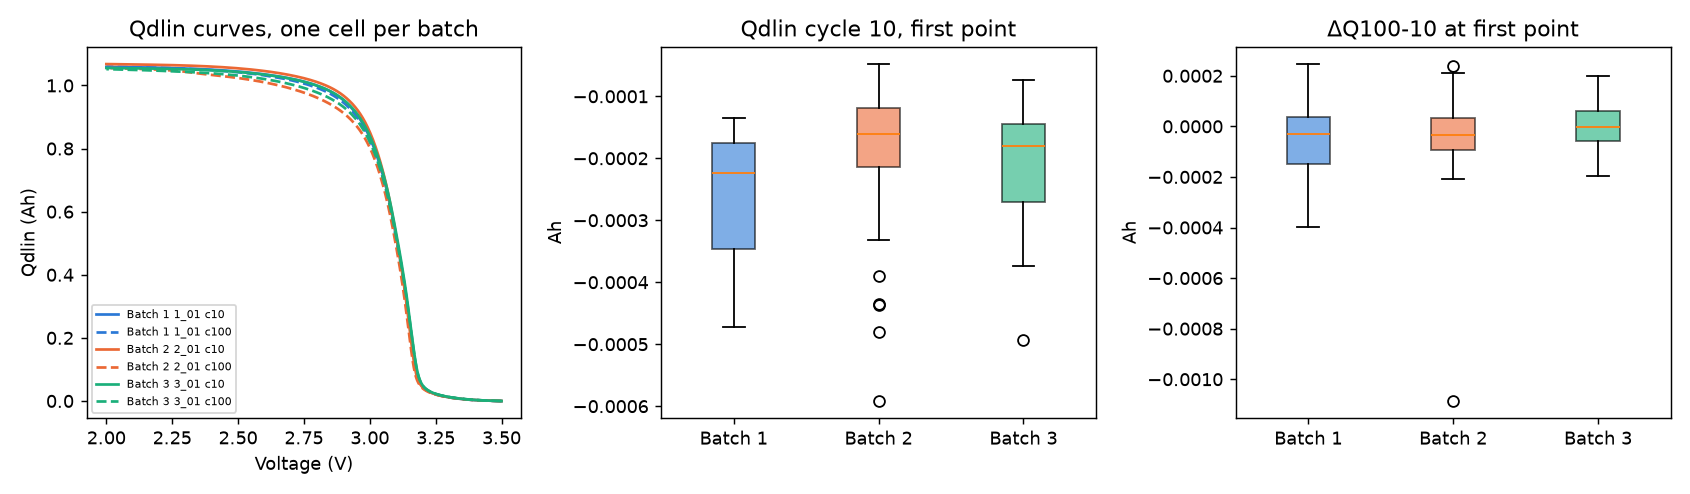

In [14]:
display(Image(filename=str(FIG / 'b3_qdlin_check.png')))

- `Vdlin`은 세 배치 모두 3.5 → 2.0 V, 1,000점으로 **동일한 전압 격자**입니다.
- ΔQ의 첫 점(`dq_first`) 중앙값은 세 배치 모두 0에 가깝고(−0.004 ~ −0.035 mAh), 절댓값 최대도 약 1.1 mAh입니다. 반면 ΔQ 끝점(`dq_last`)의 배치 중앙값은 −3.4 ~ −11.5 mAh입니다. 시작점 차이는 피처 신호보다 한 자릿수 이상 작습니다.
- 결론: **Qdlin 곡선의 절대값을 배치 간에 직접 비교하면 왜곡될 수 있지만, 우리는 같은 셀 안의 차이(ΔQ)만 쓰므로 시작점 오프셋이 상쇄되어 보정이 필요 없습니다.** `preprocess.py`는 수정하지 않았습니다.

### 6-2. Batch 3 이상치
원논문은 데이터 품질 문제로 Batch 3 일부 셀을 secondary test에서 뺐습니다(공개 로딩 스크립트 기준 `3_03`, `3_24`, `3_33`, `3_38`, `3_43`, `3_44`; 이 중 `3_24`, `3_33`은 이미 수명 라벨이 없음). 로거 지표 6개(사이클 10–100 누락, Qd 이상값, IR 0/결측 비율, 온도 급변, 충전시간 이상, Qd 급변)를 Batch 3 중앙값 + 5·MAD 기준으로 플래그했습니다.

In [15]:
flag_cols = [c for c in b3out.columns if c.startswith('flag_')]
summary = b3out.assign(flagged=b3out.n_flags > 0).groupby('paper_excluded').agg(
    cells=('cell_id', 'size'), flagged=('flagged', 'sum'))
display(summary)
b3out[b3out.paper_excluded][['cell_id', 'has_label', 'cycle_life', 'tavg_jump_max', 'qd_jump_max', 'n_flags'] + flag_cols]

,cells,flagged
paper_excluded,,
False,40,9
True,6,3


,cell_id,has_label,cycle_life,tavg_jump_max,qd_jump_max,n_flags,flag_missing_cycles_10_100,flag_qd_glitch_count,flag_ir_zero_or_nan_frac,flag_tavg_jump_max,flag_chargetime_glitch_count,flag_qd_jump_max
2,3_03,True,1267.0,0.8919,0.0009,0,False,False,False,False,False,False
23,3_24,False,NaN,1.1470,0.0026,1,False,False,False,True,False,False
32,3_33,False,NaN,1.4950,0.0025,1,False,False,False,True,False,False
37,3_38,True,1390.0,3.4628,0.0657,2,False,False,False,True,False,True
42,3_43,True,1642.0,1.0442,0.0012,0,False,False,False,False,False,False
43,3_44,True,1046.0,0.9335,0.0012,0,False,False,False,False,False,False


In [16]:
p3 = pred[(pred.model == FINAL) & (pred.split == 'secondary')]
p3[p3.batch3_outlier][['cell_id', 'cycle_life', 'predicted', 'abs_pct_error']].round(1)

,cell_id,cycle_life,predicted,abs_pct_error
342,3_03,1267.0,1378.3,8.8
375,3_38,1390.0,1554.9,11.9
380,3_43,1642.0,1051.6,36.0
381,3_44,1046.0,1057.7,1.1


- 논문 제외 4셀(라벨 있음) 중 우리 지표로 플래그된 셀은 **`3_38` 하나**입니다(온도 급변 3.46 °C, Qd 급변 0.066 Ah). 나머지 3셀은 우리 지표로는 뚜렷하지 않습니다. 반대로 논문이 제외하지 않은 셀 중에도 플래그된 셀이 있습니다(온도 급변·Qd 급변 플래그 1–2개).
- 그래서 제외 목록은 **원논문 기준을 그대로** 따르고, 전체 44셀과 제외 40셀을 함께 보고했습니다. 최종 모델의 MAPE는 44셀 11.9% / 40셀 11.7%로 차이가 0.2%p뿐이어서, 결론은 이상치 처리에 민감하지 않습니다.

## 7. 오류 분석 — 어디서, 왜 크게 틀리는가

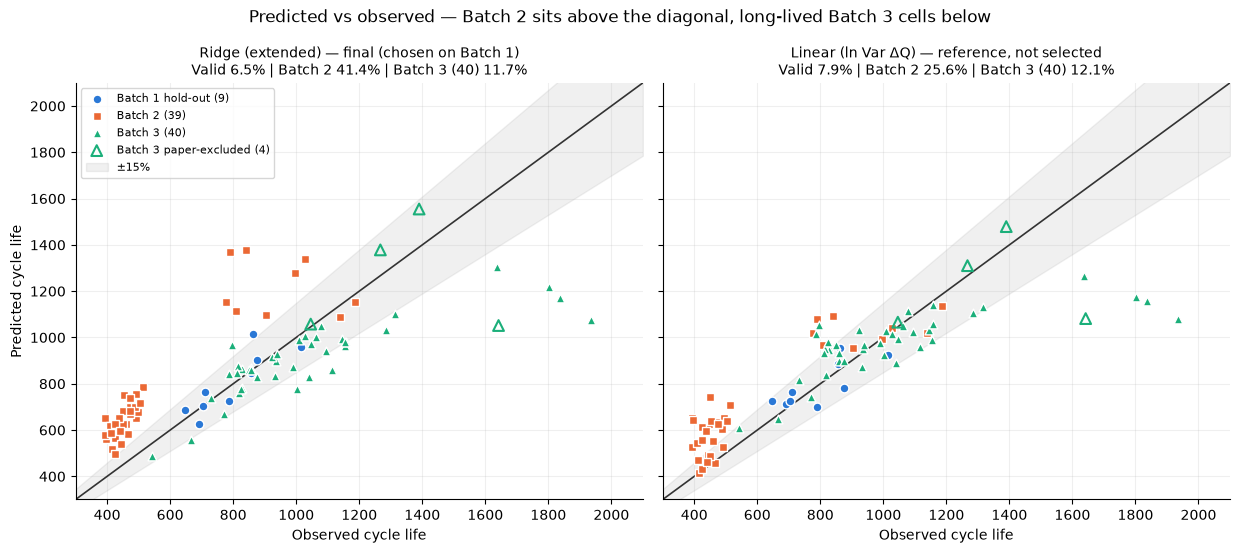

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.6), sharex=True, sharey=True)
show = {'holdout': 'Batch 1 hold-out', 'test': 'Batch 2', 'secondary': 'Batch 3'}
for ax, name in zip(axes, [FINAL, LINEAR]):
    part = pred[(pred.model == name) & pred.split.isin(show)]
    for split, label in show.items():
        p = part[part.split == split]
        color, marker = BATCH_STYLE[p.batch.iloc[0]]
        normal, out = p[~p.batch3_outlier], p[p.batch3_outlier]
        ax.scatter(normal.cycle_life, normal.predicted, color=color, marker=marker, s=40, edgecolor='white',
                   linewidth=1, label=f'{label} ({len(normal)})', zorder=3)
        if len(out):
            ax.scatter(out.cycle_life, out.predicted, facecolor='none', edgecolor=color, marker=marker, s=60,
                       linewidth=1.5, label='Batch 3 paper-excluded (4)', zorder=3)
    lim = np.array([300, 2100])
    ax.plot(lim, lim, color='#333', lw=1.2)
    ax.fill_between(lim, lim * .85, lim * 1.15, color='#888', alpha=.12, label='±15%')
    ax.set_xlim(lim); ax.set_ylim(lim)
    m = perf[perf.model == name].set_index('stage').mape
    tag = 'final (chosen on Batch 1)' if name == FINAL else 'reference, not selected'
    ax.set_title(f"{name} — {tag}\nValid {m.valid:.1f}% | Batch 2 {m.test_b2:.1f}% | Batch 3 (40) {m.test_b3_clean:.1f}%",
                 fontsize=10)
    ax.set_xlabel('Observed cycle life')
axes[0].set_ylabel('Predicted cycle life')
axes[0].legend(loc='upper left', fontsize=8)
fig.suptitle('Predicted vs observed — Batch 2 sits above the diagonal, long-lived Batch 3 cells below')
fig.tight_layout()
fig.savefig(FIG / 'm1_predicted_vs_observed.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
final_test = pred[(pred.model == FINAL) & (pred.split == 'test')].copy()
final_test['structure'] = np.where(final_test.newstructure, 'newstructure', 'original')
final_test.sort_values('abs_pct_error', ascending=False).head(8)[
    ['cell_id', 'policy', 'structure', 'cycle_life', 'predicted', 'residual', 'abs_pct_error']].round(1)

,cell_id,policy,structure,cycle_life,predicted,residual,abs_pct_error
310,2_10,5.6C(26%)-4.5C-newstructure,newstructure,791.0,1370.6,579.6,73.3
328,2_30,5.2C(58%)-4C,original,452.0,750.0,298.0,65.9
307,2_07,3.6C(9%)-5C,original,393.0,650.6,257.6,65.5
337,2_45,5.2C(58%)-4C-newstructure,newstructure,841.0,1377.9,536.9,63.8
335,2_43,5.2C(50%)-4.25C,original,474.0,738.1,264.1,55.7
301,2_01,5.2C(58%)-4C,original,477.0,742.4,265.4,55.6
324,2_26,5.2C(58%)-4C,original,493.0,757.4,264.4,53.6
311,2_11,4.8C(80%)-4.8C,original,492.0,754.0,262.0,53.3


In [19]:
breakdown[breakdown.model.isin([FINAL, LINEAR])].set_index(['model', 'subgroup'])[
    ['n', 'over_predicted', 'mean_residual', 'rmse', 'mape']].round(1)

n  over_predicted  mean_residual   rmse  mape
model              subgroup                                                                     
Linear (ln Var ΔQ) all                            39              35          119.9  153.0  25.6
                   short life (< 500)             28              27          125.5  147.1  28.4
                   life >= 500                    11               8          105.6  167.2  18.6
                   below train range (< 534)      30              29          128.2  148.6  28.6
                   inside train range (534-1074)   7               6          142.8  182.8  17.8
                   newstructure                    9               6           92.2  166.9  15.5
                   original structure             30              29          128.2  148.6  28.6
Ridge (extended)   all                            39              37          215.9  244.9  41.4
                   short life (< 500)             28              28          194.0  201.9  43.2
                   life >= 500                    11               9          271.6  329.9  36.9
                   below train range (< 534)      30              30          197.2  205.0  43.5
                   inside train range (534-1074)   7               7          369.5  391.6  43.3
                   newstructure                    9               7          278.0  346.0  34.5
                   original structure             30              30          197.2  205.0  43.5

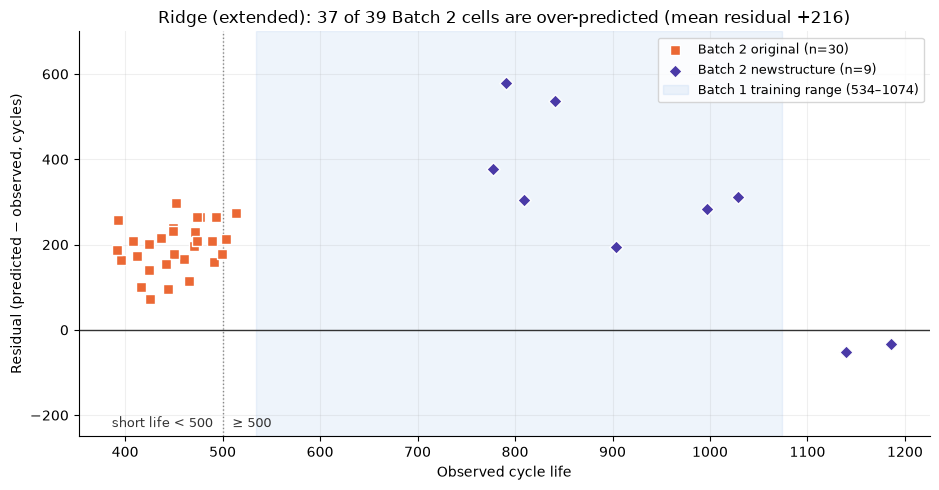

In [20]:
train_life = pred[(pred.model == FINAL) & (pred.split == 'train')].cycle_life
fig, ax = plt.subplots(figsize=(9.5, 5))
for structure, marker, color in (('original', 's', '#eb6834'), ('newstructure', 'D', '#4a3aa7')):
    p = final_test[final_test.structure == structure]
    ax.scatter(p.cycle_life, p.residual, marker=marker, color=color, s=46, edgecolor='white', linewidth=1,
               label=f'Batch 2 {structure} (n={len(p)})', zorder=3)
ax.axhline(0, color='#333', lw=1)
ax.axvspan(train_life.min(), train_life.max(), color='#2a78d6', alpha=.08,
           label=f'Batch 1 training range ({train_life.min():.0f}–{train_life.max():.0f})')
ax.axvline(500, color='#888', lw=1, ls=':')
ax.set_ylim(-250, 700)
ax.text(490, -235, 'short life < 500', ha='right', va='bottom', fontsize=9, color='#333')
ax.text(510, -235, '≥ 500', ha='left', va='bottom', fontsize=9, color='#333')
ax.set_xlabel('Observed cycle life')
ax.set_ylabel('Residual (predicted − observed, cycles)')
over = int((final_test.residual > 0).sum())
ax.set_title(f'{FINAL}: {over} of {len(final_test)} Batch 2 cells are over-predicted '
             f'(mean residual {final_test.residual.mean():+.0f})')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'm3_batch2_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

**배치별 피처 이동이 예측에 주는 효과.** Ridge 계수(log 수명 공간, Batch 1 표준화 단위)에 각 배치의 피처 중앙값 이동(z)을 곱하면, 그 피처가 배치 전체의 예측을 얼마나 밀어 올리거나 내리는지 볼 수 있습니다.

In [21]:
sys.path.insert(0, str(ROOT / 'src'))
from features import load_cells
cells = load_cells()
b1 = cells[cells.batch == 'Batch 1']
w = coef[coef.model == FINAL].set_index('feature').weight
rows = []
for b in ('Batch 2', 'Batch 3'):
    part = cells[cells.batch == b]
    for f, wt in w.items():
        z = (part[f].median() - b1[f].mean()) / b1[f].std(ddof=0)
        rows.append({'batch': b, 'feature': f, 'weight': wt, 'median_shift_z': z, 'log_effect': wt * z,
                     'prediction_factor': np.exp(wt * z)})
shift = pd.DataFrame(rows).set_index(['batch', 'feature'])
shift.round(3)

weight  median_shift_z  log_effect  prediction_factor
batch   feature                                                                    
Batch 2 ln_dq_variance        -0.169           1.323      -0.224              0.799
        qd_100                 0.068           2.139       0.145              1.156
        early_qd_slope_clean  -0.027           1.348      -0.036              0.965
Batch 3 ln_dq_variance        -0.169          -1.674       0.283              1.328
        qd_100                 0.068          -1.644      -0.111              0.895
        early_qd_slope_clean  -0.027           0.170      -0.005              0.995

- **Batch 2: 39셀 중 37셀 과대예측**(평균 잔차 +216회). 원래 구조 30셀은 모두 학습 최솟값(534회)보다 짧은 외삽 구간이고 MAPE 43.5%, `newstructure` 9셀도 34.5%입니다. 학습 범위(534–1,074회) **안쪽** 7셀도 43.3%(Linear 17.8%)여서 외삽만으로는 설명되지 않습니다. 가장 크게 틀린 셀은 `2_10`(+73%), `2_30`, `2_07`, `2_45`(+64–66%)입니다.
- **`qd_100`이 Batch 2에서 반대 방향으로 작동합니다.** Batch 2의 `qd_100`은 Batch 1보다 **+2.1 SD** 높습니다(초기 용량이 큰 셀 로트로 보임). Batch 1에서 배운 "용량이 크면 수명이 길다"는 관계 때문에 이 항 하나가 예측을 약 **1.16배** 올립니다. 그런데 Batch 2는 오히려 같은 ΔQ에서 Batch 1 직선보다 수명이 짧은(0.76배, 02 노트북) 배치라, 두 효과가 겹쳐 과대예측이 커졌습니다. 오차율과 `qd_100`의 Spearman ρ는 +0.49입니다.
- **Batch 3에서는 `qd_100`이 −1.6 SD**여서 예측을 약 0.89배 낮추지만, Batch 3는 ΔQ–수명 관계가 Batch 1 직선과 일치하는(0.98배) 배치이고, 피해가 작은 것과 부합합니다. Batch 3 오차는 주로 **장수명 외삽**입니다: 학습 최대(1,074회)보다 긴 16셀의 MAPE는 20.3%(평균 잔차 −272회, 과소예측), 그 이하 28셀은 7.2%입니다.
- 참고로 같은 셀에 대해 `ln_dq_variance` 단일 피처 Linear는 Batch 2 25.6%, Batch 3(40셀) 12.1%입니다(선택에 미사용). Batch 1 안 검증은 Ridge를 골랐지만, 배치가 바뀌면 `qd_100`의 이동이 이득을 상쇄합니다.

## 8. 보조 진단 (선택에 미사용)

### 8-1. Leave-one-batch-out
두 배치로 학습하고 남은 배치를 평가합니다(최종 모델과 Linear 기준, 피처·target은 Batch 1 선택 그대로).

In [22]:
lobo.set_index(['model', 'held_out']).round(1)

n_train   n   rmse    mae  mape
model              held_out                                 
Linear (ln Var ΔQ) Batch 1        83  36  102.6   88.7  11.5
                   Batch 2        80  39  146.3  119.9  22.6
                   Batch 3        75  44  249.2  153.0  12.2
Ridge (extended)   Batch 1        83  36  128.1  109.4  13.4
                   Batch 2        80  39  274.5  221.8  37.9
                   Batch 3        75  44  247.6  160.7  13.6

Batch 1 + 3(80셀)으로 학습해도 Batch 2 MAPE는 Ridge 37.9%, Linear 22.6%로 큽니다. 표본 수보다 **Batch 2 고유의 조건 차이**가 원인이라는 뜻입니다.

### 8-2. 새 배치 보정: 수준 이동만 맞추면 되는가?
Batch 2 셀 *k*개를 수명 끝까지 시험했다고 가정하고, 그 셀들의 `log(실제/예측)` 평균 하나로 보정한 뒤 **나머지 셀**에서 오차를 잽니다(무작위 500회).

,model,calibration_cells,eval_cells,rmse_mean,rmse_p90,mape_mean
0,Linear (ln Var ΔQ),0,39,153.03,153.03,25.61
1,Linear (ln Var ΔQ),3,36,113.89,137.53,14.56
2,Linear (ln Var ΔQ),5,34,108.24,123.67,13.78
3,Linear (ln Var ΔQ),10,29,104.33,119.25,13.22
4,Ridge (extended),0,39,244.86,244.86,41.41
5,Ridge (extended),3,36,110.85,124.44,11.27
6,Ridge (extended),5,34,107.89,119.52,10.43
7,Ridge (extended),10,29,103.91,119.17,9.81


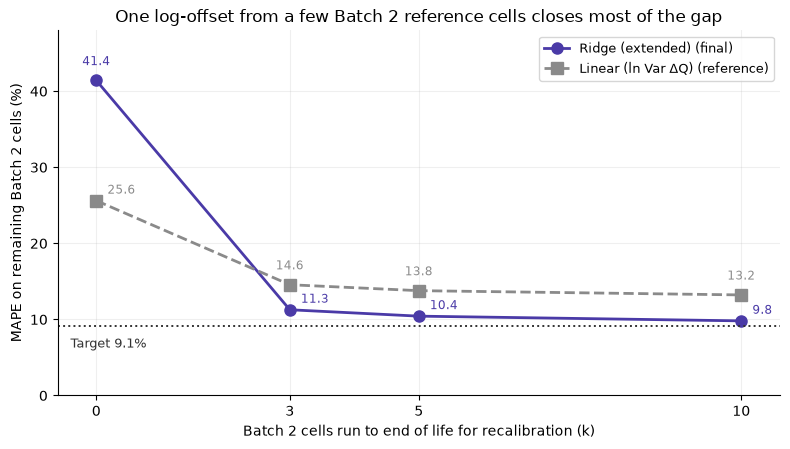

In [23]:
display(recal)
fig, ax = plt.subplots(figsize=(8, 4.6))
for name, color, marker, ls in ((FINAL, FINAL_COLOR, 'o', '-'), (LINEAR, REF_COLOR, 's', '--')):
    part = recal[recal.model == name]
    tag = 'final' if name == FINAL else 'reference'
    ax.plot(part.calibration_cells, part.mape_mean, marker=marker, color=color, lw=2, ms=8, ls=ls, label=f'{name} ({tag})')
    other = recal[recal.model != name].set_index('calibration_cells').mape_mean
    for _, r in part.iterrows():
        above = r.mape_mean >= other.get(r.calibration_cells, -1)
        ax.annotate(f'{r.mape_mean:.1f}', (r.calibration_cells, r.mape_mean), textcoords='offset points',
                    xytext=(0, 9) if above else (8, 3), ha='center' if above else 'left', va='bottom',
                    fontsize=8.5, color=color)
ax.axhline(TARGET_MAPE, color='#333', ls=':', lw=1.4)
ax.text(-.4, TARGET_MAPE - 2.8, f'Target {TARGET_MAPE}%', ha='left', fontsize=9, color='#333')
ax.set_xlabel('Batch 2 cells run to end of life for recalibration (k)')
ax.set_ylabel('MAPE on remaining Batch 2 cells (%)')
ax.set_xticks([0, 3, 5, 10])
ax.set_xlim(-.6, 10.6)
ax.set_ylim(0, 48)
ax.set_title('One log-offset from a few Batch 2 reference cells closes most of the gap')
ax.legend(loc='upper right', fontsize=9)
fig.tight_layout()
fig.savefig(FIG / 'm4_batch2_recalibration.png', dpi=150, bbox_inches='tight')
plt.show()

### 8-3. Hold-out 분할 민감도
Hold-out이 9셀뿐이라 분할 운에 따라 선택이 바뀔 수 있습니다. 분할 시드 0–19로 같은 절차(Dev CV → Hold-out 선택)를 반복했습니다. 헤드라인은 미리 정한 seed 0입니다.

In [24]:
display(sens.final_model.value_counts().to_frame('times chosen (20 splits)'))
sens.groupby('final_model')[['valid_mape', 'train_cv_mape']].describe().round(2).T

,times chosen (20 splits)
final_model,
Ridge (extended),16
Linear (ln Var ΔQ),3
Random Forest,1


final_model          Linear (ln Var ΔQ)  Random Forest  Ridge (extended)
valid_mape    count                3.00           1.00             16.00
              mean                 7.63           6.36              6.93
              std                  1.32            NaN              0.81
              min                  6.83           6.36              5.21
              25%                  6.87           6.36              6.44
              50%                  6.90           6.36              6.73
              75%                  8.03           6.36              7.43
              max                  9.16           6.36              8.63
train_cv_mape count                3.00           1.00             16.00
              mean                 9.45          12.38              6.94
              std                  0.50            NaN              0.34
              min                  8.89          12.38              6.56
              25%                  9.25          12.38              6.68
              50%                  9.60          12.38              6.82
              75%                  9.73          12.38              7.28
              max                  9.85          12.38              7.64

20개 분할 중 Ridge 16회, Linear 3회, Random Forest 1회가 선택됐습니다. Batch 1 안의 정보만으로는 Ridge 선택이 대체로 안정적이며, seed 0 결과가 예외적인 분할 운에서 나온 것이 아닙니다.

## 9. 결론

**성능 (과제 포맷).** Batch 1 안에서 정책 단위 CV와 Hold-out으로 고른 최종 모델은 **Ridge(log target, `ln_dq_variance` + `qd_100` + `early_qd_slope_clean`)**입니다. Train(Batch 1 CV) 6.6%, Valid(Batch 1 Hold-out) 6.5%, **Test(Batch 2) 41.4%**, Test(Batch 3, 40셀) 11.7%(44셀 11.9%)입니다. Gap(Train-Valid) −0.1, Gap(Valid-Test) +34.9, **Gap(Target-Test) +32.3**, Gap(Batch2-Batch3) −29.7, Gap(Target-Test, Batch 3) +2.6입니다.

**해석.**
1. Batch 1 안에서는 목표(9.1%)보다 좋고 과적합 징후도 없습니다. 실패는 **배치가 바뀔 때** 일어납니다.
2. Batch 2에서의 큰 Gap은 (a) ΔQ–수명 관계의 수준 이동(Batch 2는 Batch 1 직선 대비 0.76배 수명), (b) Batch 1에서 채택된 `qd_100`이 Batch 2에서 +2.1 SD 이동해 예측을 더 끌어올린 것, (c) Batch 2 원래 구조 30셀이 모두 학습 범위(534–1,074회) 아래에 있는 외삽, (d) 작은 학습셋(36셀, 정책 20개)에서 배운 용량–수명 관계를 다른 셀 로트에 그대로 적용한 것 때문입니다. 또한 과제의 Batch 2는 원논문 124셀에 없는 배치라 논문 Target과 조건이 다릅니다.
3. Batch 3가 Target에 가까운(+2.6%p) 것은 Batch 3의 ΔQ–수명 관계가 Batch 1 직선과 일치하는 것(0.98배)과 부합합니다. Gap(Batch2-Batch3)이 −29.7%p로 크게 벌어진 것은 **확장 피처, 특히 `qd_100`이 Batch 1과 비슷한 조건의 배치에서만 통하는 관계에 맞춰졌다**는 신호입니다.
4. 선택에 쓰지 않은 참고값으로, 단일 피처 Linear는 Batch 2 25.6% / Batch 3 12.1%였습니다. Batch 1 안의 검증만으로는 이 차이를 미리 알 수 없었고, 과제 원칙(선택은 Batch 1 안에서만)에 따라 사후 교체하지 않았습니다.

**개선 방향.** Batch 2 셀 3개만 수명 끝까지 시험해 보정값 하나를 맞추면 최종 모델의 나머지 셀 MAPE가 41.4% → 11.3%, 10셀이면 9.8%로 Target 근처까지 내려옵니다. 새 배치에서는 피처를 늘리기보다 **소수 기준 셀로 수준을 보정**하는 절차가 효과적입니다.

In [25]:
# Consistency check: headline numbers quoted in the markdown above must equal the results CSVs.
r = report.set_index(['section', 'item']).mape
quoted = {('Regression', 'Train (Batch 1 CV)'): 6.6, ('Regression', 'Valid (Batch 1 Hold-out)'): 6.5,
          ('Regression', 'Test (Batch 2)'): 41.4, ('Regression', 'Gap (Train-Valid)'): -0.1,
          ('Regression', 'Gap (Valid-Test)'): 34.9, ('Regression', 'Gap (Target-Test)'): 32.3,
          ('Batch 3', 'Test (Batch 3)'): 11.7, ('Batch 3', 'Gap (Batch2-Batch3)'): -29.7,
          ('Batch 3', 'Gap (Target-Test)'): 2.6}
for k, v in quoted.items():
    assert round(r[k], 1) == v, (k, r[k], v)
m = perf.set_index(['model', 'stage']).mape
assert round(m[(FINAL, 'test_b3_all')], 1) == 11.9 and round(m[(LINEAR, 'test_b2')], 1) == 25.6
assert round(m[(LINEAR, 'test_b3_clean')], 1) == 12.1
rc = recal.set_index(['model', 'calibration_cells']).mape_mean
assert round(rc[(FINAL, 3)], 1) == 11.3 and round(rc[(FINAL, 10)], 1) == 9.8
assert sens.final_model.value_counts().to_dict() == {'Ridge (extended)': 16, 'Linear (ln Var ΔQ)': 3, 'Random Forest': 1}
assert round(sib_mape[(FINAL, True)], 1) == 5.9 and round(sib_mape[(FINAL, False)], 1) == 7.6
print('All quoted numbers match results/.')

All quoted numbers match results/.
